In [1]:
from pathlib import Path
import kagglesdk.kaggle_env as kaggle_env

if not hasattr(kaggle_env, "get_web_endpoint"):
    kaggle_env.get_web_endpoint = kaggle_env.get_endpoint

import kagglehub
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PolynomialFeatures,
    RobustScaler,
    StandardScaler,
)
from sklearn.impute import SimpleImputer

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


/Users/lemon7z/PycharmProjects/DataScience-customer-personality-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
class TotalSpendingRegressor:
    def __init__(self):
        self.figure_dir = Path("figures")
        self.result_dir = Path("results")
        self.raw_df = self.load_dataset_from_kaggle()


    def load_dataset_from_kaggle(self):
        """
        Load Customer Personality Analysis dataset.
        Kaggle original file is a CSV-like text file.
        """
        path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")
        df = pd.read_csv(path + '/marketing_campaign.csv', sep='\t')
        return df.copy()
    def preprocessing(self):
        temp_df = self.create_features(self.raw_df)
        self.df = self.clean_data(temp_df)

    def save_and_show_plot(self, filename):
        """
        Save the current matplotlib figure to the figures directory and show it.
        """
        self.figure_dir.mkdir(exist_ok=True)
        safe_filename = "".join(
            char.lower() if char.isalnum() else "_"
            for char in filename
        ).strip("_")
        figure_path = self.figure_dir / f"{safe_filename}.png"
        plt.savefig(figure_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {figure_path}")
        plt.show()
        plt.close()

    def create_features(self, df):
        """
        Create derived variables according to the team proposal.
        """
        df = df.copy()

        df["Dt_Customer"] = pd.to_datetime(
            df["Dt_Customer"],
            format="%d-%m-%Y",
            errors="coerce"
        )

        # Create Age from Year_Birth.
        df["Age"] = 2014 - df["Year_Birth"]

        # Customer tenure in days.
        reference_date = df["Dt_Customer"].max()
        df["Customer_Days"] = (reference_date - df["Dt_Customer"]).dt.days

        # Family-related feature.
        df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

        # Total spending from six product spending columns.
        spending_cols = [
            "MntWines",
            "MntFruits",
            "MntMeatProducts",
            "MntFishProducts",
            "MntSweetProducts",
            "MntGoldProds",
        ]
        df["TotalSpending"] = df[spending_cols].sum(axis=1)

        # Total purchases from actual purchase count variables.
        purchase_cols = [
            "NumDealsPurchases",
            "NumWebPurchases",
            "NumCatalogPurchases",
            "NumStorePurchases",
        ]
        df["TotalPurchases"] = df[purchase_cols].sum(axis=1)

        # Total number of accepted previous campaigns.
        campaign_cols = [
            "AcceptedCmp1",
            "AcceptedCmp2",
            "AcceptedCmp3",
            "AcceptedCmp4",
            "AcceptedCmp5",
        ]
        df["CampaignAcceptedTotal"] = df[campaign_cols].sum(axis=1)

        return df

    def clean_data(self, df):
        """
        Clean dirty data and remove unnecessary columns.
        """
        df = df.copy()

        # Group rare marital status categories into Other.
        rare_status = ["Alone", "Absurd", "YOLO"]
        df["Marital_Status"] = df["Marital_Status"].replace(rare_status, "Other")

        # Remove unrealistic ages.
        df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

        # Remove extreme income outlier.
        # The proposal notes Income has a maximum value of 666,666.
        df = df[df["Income"].isna() | (df["Income"] <= 200000)]


        # Remove identifier and constant/date columns.
        drop_cols = [
            "ID",
            "Year_Birth",
            "Dt_Customer",
            "Z_CostContact",
            "Z_Revenue",
        ]
        df = df.drop(columns=[col for col in drop_cols if col in df.columns])

        return df

    def data_inspection(self, df=None):
        if df is None:
            df = self.raw_df
        corr_matrix = df.corr(method='pearson', numeric_only=True)
        print("--- correlation matrix ---")
        print(corr_matrix)

        plt.figure(figsize=(20, 20))

        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
        plt.title('Correlation Matrix Heatmap', fontsize=15)
        self.save_and_show_plot("correlation_matrix_heatmap")

    def build_preprocessor(self, X, scaler_name="standard", encoder_name="onehot"):
        """
        Build preprocessing pipeline:
        - Numeric columns: median imputation + selected scaling method
        - Categorical columns: most frequent imputation + selected encoding method
        """
        categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
        numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

        scalers = {
            "standard": StandardScaler(),
            "minmax": MinMaxScaler(),
            "robust": RobustScaler(),
        }
        encoders = {
            "onehot": OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            "ordinal": OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        }

        numeric_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", scalers[scaler_name]),
            ]
        )

        categorical_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", encoders[encoder_name]),
            ]
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, numeric_cols),
                ("cat", categorical_transformer, categorical_cols),
            ]
        )

        return preprocessor

    def find_best_combinations(self, df, top_n=5):
        """
        Run model selection experiments under one top-level function.

        It evaluates combinations of:
        - numeric scaling methods
        - categorical encoding methods
        - learning models and model parameters
        - cross-validation and hold-out test metrics
        """
        print("\n==============================")
        print("Model Selection: Top Combinations")
        print("==============================")

        selected_features = [
            "Income",
            "Age",
            "Kidhome",
            "Teenhome",
            "Customer_Days",
            "TotalChildren",
            "Education",
            "Marital_Status",
        ]
        X = df[selected_features]
        y = df["TotalSpending"]

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42,
        )
        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        model_configs = [
            ("LinearRegression", LinearRegression()),
            ("Ridge_alpha_0.1", Ridge(alpha=0.1)),
            ("Ridge_alpha_1.0", Ridge(alpha=1.0)),
            ("Ridge_alpha_10.0", Ridge(alpha=10.0)),
            ("Lasso_alpha_0.1", Lasso(alpha=0.1, max_iter=10000)),
            ("Lasso_alpha_1.0", Lasso(alpha=1.0, max_iter=10000)),
            (
                "RandomForest_depth_5",
                RandomForestRegressor(
                    n_estimators=200,
                    max_depth=5,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
            (
                "RandomForest_depth_10",
                RandomForestRegressor(
                    n_estimators=200,
                    max_depth=10,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
            (
                "GradientBoosting_lr_0.05",
                GradientBoostingRegressor(
                    learning_rate=0.05,
                    n_estimators=200,
                    max_depth=3,
                    random_state=42,
                ),
            ),
            (
                "GradientBoosting_lr_0.1",
                GradientBoostingRegressor(
                    learning_rate=0.1,
                    n_estimators=200,
                    max_depth=3,
                    random_state=42,
                ),
            ),
        ]

        results = []
        for scaler_name in ["standard", "minmax", "robust"]:
            for encoder_name in ["onehot", "ordinal"]:
                preprocessor = self.build_preprocessor(
                    X,
                    scaler_name=scaler_name,
                    encoder_name=encoder_name,
                )

                for model_name, model in model_configs:
                    pipeline = Pipeline(
                        steps=[
                            ("preprocessor", preprocessor),
                            ("model", model),
                        ]
                    )

                    cv_r2_scores = cross_val_score(
                        pipeline,
                        X,
                        y,
                        cv=cv,
                        scoring="r2",
                    )
                    cv_mae_scores = -cross_val_score(
                        pipeline,
                        X,
                        y,
                        cv=cv,
                        scoring="neg_mean_absolute_error",
                    )

                    pipeline.fit(X_train, y_train)
                    y_pred = pipeline.predict(X_test)

                    test_mse = mean_squared_error(y_test, y_pred)
                    results.append(
                        {
                            "scaler": scaler_name,
                            "encoder": encoder_name,
                            "model": model_name,
                            "cv_r2_mean": cv_r2_scores.mean(),
                            "cv_r2_std": cv_r2_scores.std(),
                            "cv_mae_mean": cv_mae_scores.mean(),
                            "test_r2": r2_score(y_test, y_pred),
                            "test_mae": mean_absolute_error(y_test, y_pred),
                            "test_rmse": np.sqrt(test_mse),
                        }
                    )

        results_df = pd.DataFrame(results).sort_values(
            by=["cv_r2_mean", "test_r2"],
            ascending=False,
        )

        print(f"\nTop {top_n} combinations by mean CV R2:")
        top_results = results_df.head(top_n)
        print(top_results.to_string(index=False))

        self.result_dir.mkdir(exist_ok=True)
        results_df.to_csv(self.result_dir / "model_selection_results.csv", index=False)
        top_results.to_csv(self.result_dir / "top_5_model_combinations.csv", index=False)
        print(f"\nSaved results: {self.result_dir / 'model_selection_results.csv'}")
        print(f"Saved top {top_n}: {self.result_dir / 'top_5_model_combinations.csv'}")

        self.model_selection_results = results_df
        return results_df

    def run_regression(self, df):
        """
        Regression task:
        Predict TotalSpending.
        """
        print("\n==============================")
        print("Regression: Predict TotalSpending")
        print("==============================")

        y = df["TotalSpending"]

        # Proposal-based simple regression input features.
        selected_features = ["Income", "Age", "Kidhome", "Teenhome"]
        X = df[selected_features]

        preprocessor = self.build_preprocessor(X)

        models = {
            "Multiple Linear Regression": LinearRegression(),
            "Polynomial Regression degree 2": Pipeline(
                steps=[
                    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                    ("linear", LinearRegression()),
                ]
            ),
        }

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42,
        )

        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        for model_name, model in models.items():
            print(f"\n--- {model_name} ---")

            reg = Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", model),
                ]
            )

            cv_scores = cross_val_score(reg, X, y, cv=cv, scoring="r2")
            print("5-fold CV R2:", cv_scores)
            print("Mean CV R2:", cv_scores.mean())

            reg.fit(X_train, y_train)
            y_pred = reg.predict(X_test)

            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            print("Test R2:", r2)
            print("MAE:", mae)
            print("RMSE:", rmse)

            if model_name == "Multiple Linear Regression":
                coef_df = pd.DataFrame(
                    {
                        "Feature": selected_features,
                        "Coefficient": reg.named_steps["model"].coef_,
                    }
                ).sort_values("Coefficient", ascending=False)

                print("\nCoefficient:")
                print(coef_df)

            result_df = pd.DataFrame(
                {
                    "Actual_TotalSpending": y_test,
                    "Predicted_TotalSpending": y_pred,
                    "Error": y_test - y_pred,
                }
            )
            print("\nPrediction result sample:")
            print(result_df.head(10))

            self.plot_actual_vs_predicted(y_test, y_pred, model_name)
            self.plot_regression_curve(reg, X, y, selected_features, model_name)

    def plot_actual_vs_predicted(self, y_test, y_pred, model_name):
        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.6)
        plt.plot(
            [y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="red",
        )
        plt.xlabel("Actual TotalSpending")
        plt.ylabel("Predicted TotalSpending")
        plt.title(f"Actual vs Predicted TotalSpending ({model_name})")
        plt.tight_layout()
        self.save_and_show_plot(f"actual_vs_predicted_{model_name}")

    def plot_regression_curve(self, fitted_model, X, y, selected_features, model_name, feature="Income"):
        """
        Plot the fitted regression curve for one feature while holding the other
        model features at their median values.
        """
        X_curve = pd.DataFrame(
            np.tile(X[selected_features].median().values, (200, 1)),
            columns=selected_features,
        )
        X_curve[feature] = np.linspace(X[feature].min(), X[feature].max(), 200)
        y_curve = fitted_model.predict(X_curve)

        plt.figure(figsize=(8, 5))
        plt.scatter(X[feature], y, alpha=0.35, label="Actual")
        plt.plot(X_curve[feature], y_curve, color="red", linewidth=2, label="Regression curve")
        plt.xlabel(feature)
        plt.ylabel("TotalSpending")
        plt.title(f"{model_name}: {feature} vs TotalSpending")
        plt.legend()
        plt.tight_layout()
        self.save_and_show_plot(f"{model_name}_{feature}_regression_curve")




In [7]:
reg = TotalSpendingRegressor()
df = reg.load_dataset_from_kaggle()

In [71]:
df

,ID,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_CostContact,Z_Revenue,Response,Age,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,HasPartner
0,5524,1957,Single,58138.0,0,0,04-09-2012,58,635,88,...,3,11,1,57,False,False,True,False,False,0
1,2174,1954,Single,46344.0,1,1,08-03-2014,38,11,1,...,3,11,0,60,False,False,True,False,False,0
2,4141,1965,Together,71613.0,0,0,21-08-2013,26,426,49,...,3,11,0,49,False,False,True,False,False,1
3,6182,1984,Together,26646.0,1,0,10-02-2014,26,11,4,...,3,11,0,30,False,False,True,False,False,1
4,5324,1981,Married,58293.0,1,0,19-01-2014,94,173,43,...,3,11,0,33,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Married,61223.0,0,1,13-06-2013,46,709,43,...,3,11,0,47,False,False,True,False,False,1
2236,4001,1946,Together,64014.0,2,1,10-06-2014,56,406,0,...,3,11,0,68,False,False,False,False,True,1
2237,7270,1981,Divorced,56981.0,0,0,25-01-2014,91,908,48,...,3,11,0,33,False,False,True,False,False,0
2238,8235,1956,Together,69245.0,0,1,24-01-2014,8,428,30,...,3,11,0,58,False,False,False,True,False,1


AgeGroup
Income
Education
Marital_Status
Kidhome
Teenhome
Recency
NumWebPurchases
NumCatalogPurchases
NumStorePurchases
NumWebVisitsMonth

이 피쳐를 이용해서 어떤 코너의 제품을 살 지 정해보자

In [ ]:
d

여기서 우리가 예측하고자 하는거
Mnt...들
이걸로 해당 사람이 어떤걸 살 지 예측하고 온라인 접속 / 마케팅 시 해당 상품 주력으로 광고할 수 있음

## preprocessing

나이 변환

In [18]:
df['Age'] = 2014 - df['Year_Birth']

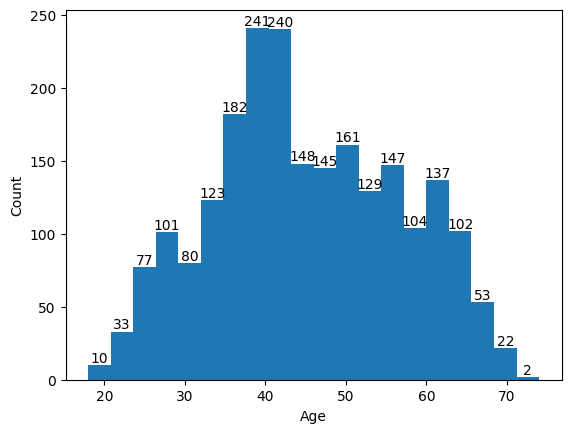

In [21]:
counts, bins, patches = plt.hist(df["Age"], bins=20)

for count, patch in zip(counts, patches):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    plt.text(
        x,
        y,
        int(count),
        ha="center",
        va="bottom"
    )

plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

도표 결과 100세 이상은 이상치로 분류 해당 제거 필

In [20]:
df  = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

Income feature 분석

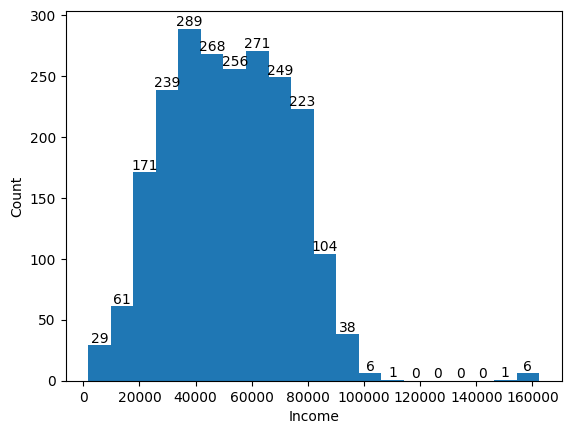

In [30]:
counts, bins, patches = plt.hist(df["Income"], bins=20)

for count, patch in zip(counts, patches):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    plt.text(
        x,
        y,
        int(count),
        ha="center",
        va="bottom"
    )

plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

600000 이상은 이상치로 보여짐 제거 필

0       False
1       False
2       False
3       False
4       False
        ...  
2235    False
2236    False
2237    False
2238    False
2239    False
Name: Income, Length: 2237, dtype: bool

In [29]:
df = df[df['Income'] < 300000]

Education에 대한 전처리 one hot encoding으로 처리함 (범주형 아니기에)

In [31]:
df = pd.get_dummies(df, columns=["Education"], drop_first=False)

In [33]:
rare_status = ["Alone", "Absurd", "YOLO"]

df["Marital_Status"] = df["Marital_Status"].replace(
    rare_status,
    "Other"
)

df["Marital_Status"] = df["Marital_Status"].fillna(
    df["Marital_Status"].mode()[0]
)

결혼여부

In [37]:
df["HasPartner"] = df["Marital_Status"].isin(["Married", "Together"]).astype(int)

In [39]:
X = df[
    [
        "Age",
        "Income",
        "HasPartner",
        "Kidhome",
        "Teenhome",
        "Recency",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth",
    ]
]

In [44]:
(X)

,Age,Income,HasPartner,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,57,58138.0,0,0,0,58,3,8,10,4,7
1,60,46344.0,0,1,1,38,2,1,1,2,5
2,49,71613.0,1,0,0,26,1,8,2,10,4
3,30,26646.0,1,1,0,26,2,2,0,4,6
4,33,58293.0,1,1,0,94,5,5,3,6,5
...,...,...,...,...,...,...,...,...,...,...,...
2235,47,61223.0,1,0,1,46,2,9,3,4,5
2236,68,64014.0,1,2,1,56,7,8,2,5,7
2237,33,56981.0,0,0,0,91,1,2,3,13,6
2238,58,69245.0,1,0,1,8,2,6,5,10,3


스케일링 진행, positive skew된 데이터 일부 식별 -> log1p 변환 해야함

1. positive skew가 있는 구매 횟수 변수에 log1p 적용
2. Income 결측값 median 대체
3. StandardScaler 적용

In [55]:
log_cols = [
    "Income",
    # "NumDealsPurchases",
    # "NumWebPurchases",
    # "NumCatalogPurchases",
    # "NumStorePurchases",
    # "NumWebVisitsMonth",
]

X_processed = X.copy()

for col in log_cols:
    X_processed[col] = np.log1p(X_processed[col])

In [56]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X_processed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_processed),
    columns=X_processed.columns,
    index=X_processed.index
)

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_processed),
    columns=X_processed.columns,
    index=X_processed.index
)

In [57]:
X_scaled

,Age,Income,HasPartner,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,1.018352,0.434020,-1.349603,-0.822754,-0.929699,0.310353,0.351030,1.426865,2.503607,-0.555814,0.692181
1,1.274785,-0.016885,-1.349603,1.040021,0.908097,-0.380813,-0.168701,-1.126420,-0.571340,-1.171160,-0.132545
2,0.334530,0.848591,0.740959,-0.822754,-0.929699,-0.795514,-0.688432,1.426865,-0.229679,1.290224,-0.544908
3,-1.289547,-1.117556,0.740959,1.040021,-0.929699,-0.795514,-0.168701,-0.761665,-0.913000,-0.555814,0.279818
4,-1.033114,0.439315,0.740959,1.040021,-0.929699,1.554453,1.390492,0.332600,0.111982,0.059532,-0.132545
...,...,...,...,...,...,...,...,...,...,...,...
2235,0.163575,0.536846,0.740959,-0.822754,0.908097,-0.104347,-0.168701,1.791619,0.111982,-0.555814,-0.132545
2236,1.958607,0.625502,0.740959,2.902796,0.908097,0.241237,2.429954,1.426865,-0.229679,-0.248141,0.692181
2237,-1.033114,0.394043,-1.349603,-0.822754,-0.929699,1.450778,-0.688432,-0.761665,0.111982,2.213242,0.279818
2238,1.103830,0.781718,0.740959,-0.822754,0.908097,-1.417564,-0.168701,0.697355,0.795303,1.290224,-0.957271


예측해야하는 y 생성

In [58]:
product_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
]

total_spending = df[product_cols].sum(axis=1)
valid_target_index = total_spending[total_spending > 0].index

y = df.loc[valid_target_index, product_cols].div(
    total_spending.loc[valid_target_index],
    axis=0,
)
X_model = X_scaled.loc[valid_target_index]


In [60]:
y

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,635,88,546,172,88,88
1,11,1,6,2,1,6
2,426,49,127,111,21,42
3,11,4,20,10,3,5
4,173,43,118,46,27,15
...,...,...,...,...,...,...
2235,709,43,182,42,118,247
2236,406,0,30,0,0,8
2237,908,48,217,32,12,24
2238,428,30,214,80,30,61


shape확인으로 row 개수 일치 확인

In [62]:
print(X_model.shape, y.shape)


(2212, 11) (2212, 6)


In [68]:
models = {
    "Multiple Linear Regression": LinearRegression(),
    "Polynomial Regression degree 2": Pipeline(
        steps=[
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("linear", LinearRegression()),
        ]
    ),
}

selected_features = X_model.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.2,
    random_state=42,
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_results = {}
model_summary = []

for model_name, model in models.items():
    print(f"\n--- {model_name} ---")

    reg = Pipeline(
        steps=[
            ("model", model),
        ]
    )

    cv_scores = cross_val_score(reg, X_model, y, cv=cv, scoring="r2")
    print("5-fold CV R2:", cv_scores)
    print("Mean CV R2:", cv_scores.mean())

    reg.fit(X_train, y_train)
    y_train_pred = np.clip(reg.predict(X_train), 0, 1)
    y_pred = np.clip(reg.predict(X_test), 0, 1)

    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Train R2:", train_r2)
    print("Train MAE:", train_mae)
    print("Train RMSE:", train_rmse)
    print("Test R2:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)

    model_summary.append(
        {
            "Model": model_name,
            "Train R2": train_r2,
            "Test R2": r2,
            "Train MAE": train_mae,
            "Test MAE": mae,
            "Train RMSE": train_rmse,
            "Test RMSE": rmse,
        }
    )

    per_product_metrics = pd.DataFrame(
        {
            "Product": product_cols,
            "R2": r2_score(y_test, y_pred, multioutput="raw_values"),
            "MAE": mean_absolute_error(y_test, y_pred, multioutput="raw_values"),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred, multioutput="raw_values")),
        }
    )
    print("\nPer-product metrics:")
    print(per_product_metrics)

    if model_name == "Multiple Linear Regression":
        coef_df = pd.DataFrame(
            reg.named_steps["model"].coef_.T,
            index=selected_features,
            columns=product_cols,
        )

        print("\nCoefficient:")
        print(coef_df)

    y_pred_df = pd.DataFrame(
        y_pred,
        columns=[f"PredictedRatio_{col}" for col in product_cols],
        index=y_test.index,
    )
    y_test_df = y_test.add_prefix("Actual_")
    error_df = pd.DataFrame(
        y_test.values - y_pred,
        columns=[f"ErrorRatio_{col}" for col in product_cols],
        index=y_test.index,
    )

    result_df = pd.concat([y_test_df, y_pred_df, error_df], axis=1)

    y_pred_ratio_df = pd.DataFrame(
        y_pred,
        columns=product_cols,
        index=y_test.index,
    )
    y_pred_score_df = y_pred_ratio_df.div(y_pred_ratio_df.sum(axis=1).replace(0, np.nan), axis=0)
    y_pred_score_df = y_pred_score_df.fillna(0)

    result_df["Actual_Product"] = y_test.idxmax(axis=1)
    result_df["Recommended_Product"] = y_pred_score_df.idxmax(axis=1)
    result_df["Recommendation_Match"] = result_df["Actual_Product"] == result_df["Recommended_Product"]

    score_df = y_pred_score_df.add_prefix("RecommendationScore_")
    result_df = pd.concat([result_df, score_df], axis=1)

    print("\nPrediction result sample:")
    print(result_df.head(10))
    print("Recommendation match rate:", result_df["Recommendation_Match"].mean())

    model_results[model_name] = {
        "model": reg,
        "cv_scores": cv_scores,
        "per_product_metrics": per_product_metrics,
        "predictions": result_df,
    }



--- Multiple Linear Regression ---
5-fold CV R2: [0.42769916 0.45766071 0.44706108 0.39023175 0.4143781 ]
Mean CV R2: 0.4274061585441503
Train R2: 0.452980453217416
Train MAE: 51.36868959258879
Train RMSE: 102.8969049226684
Test R2: 0.44059300179354527
MAE: 53.53393002096835
RMSE: 109.58399366082176

Per-product metrics:
            Product        R2         MAE        RMSE
0          MntWines  0.613506  136.456915  218.231014
1         MntFruits  0.345028   20.893295   32.999470
2   MntMeatProducts  0.646061   86.680833  136.318819
3   MntFishProducts  0.380687   27.546903   44.001540
4  MntSweetProducts  0.347200   21.279866   32.624754
5      MntGoldProds  0.311077   28.345768   41.890799

Coefficient:
                      MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Age                   9.092690  -1.783917        -7.080460        -0.091141   
Income               96.006459   3.955798        45.144426         5.066338   
HasPartner           -2.566300  -0.450125      

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Multiple Linear Regression,0.452980,0.440593,51.368690,53.533930,102.896905,109.583994
1,Polynomial Regression degree 2,0.531802,0.465641,44.506776,48.831792,88.740473,99.586829


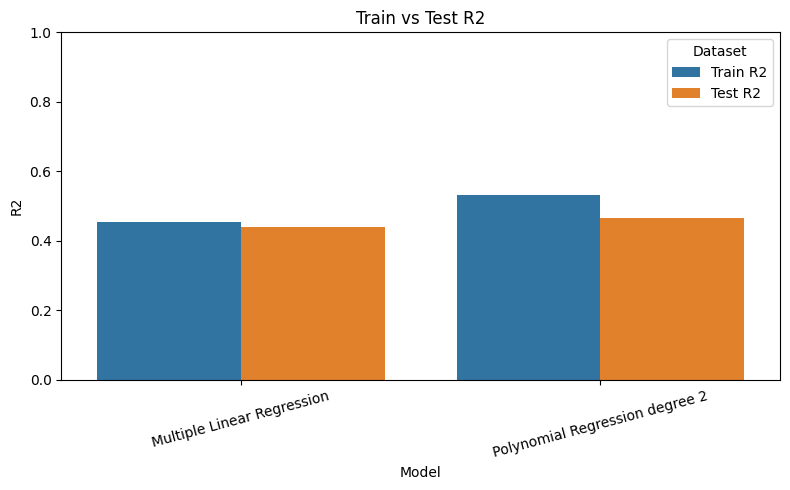

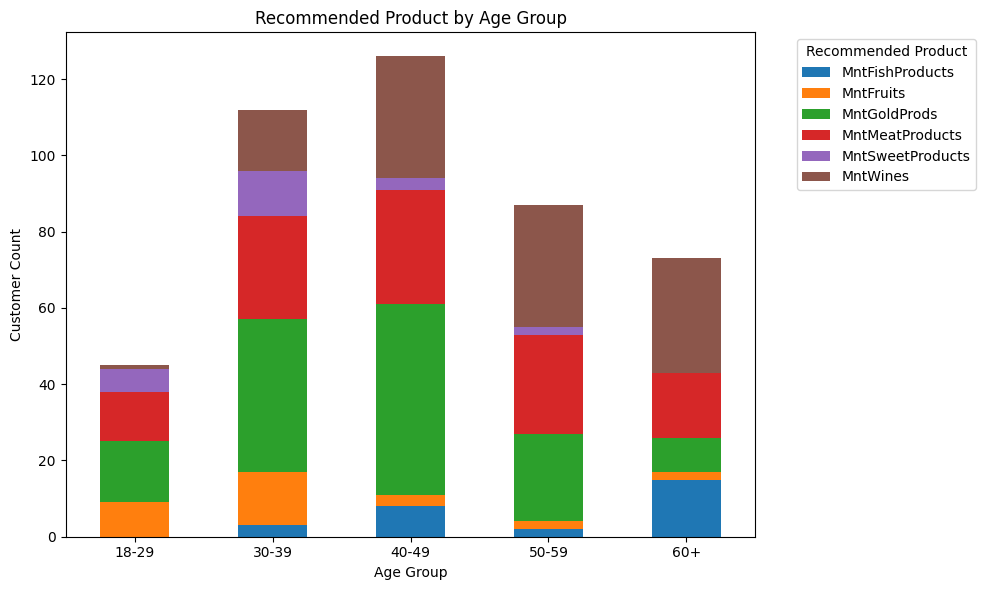

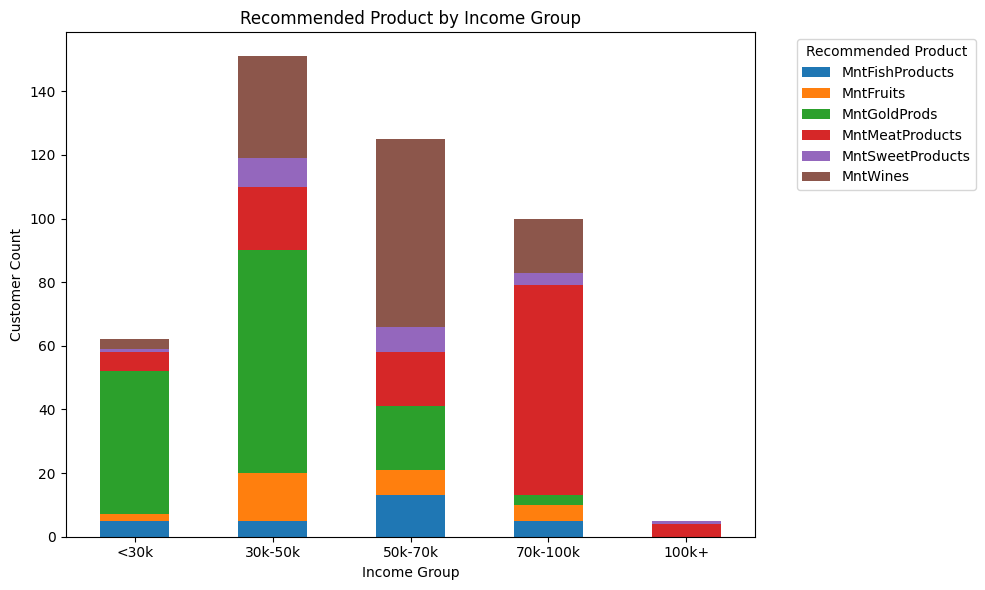

In [69]:
model_summary_df = pd.DataFrame(model_summary)
display(model_summary_df)

train_test_plot_df = model_summary_df.melt(
    id_vars="Model",
    value_vars=["Train R2", "Test R2"],
    var_name="Dataset",
    value_name="R2",
)

plt.figure(figsize=(8, 5))
sns.barplot(data=train_test_plot_df, x="Model", y="R2", hue="Dataset")
plt.title("Train vs Test R2")
plt.xlabel("Model")
plt.ylabel("R2")
plt.xticks(rotation=15)
plt.ylim(0, max(train_test_plot_df["R2"].max() + 0.1, 1.0))
plt.tight_layout()
plt.show()

final_model_name = "Multiple Linear Regression"
recommendation_df = model_results[final_model_name]["predictions"][[
    "Actual_Product",
    "Recommended_Product",
    "Recommendation_Match",
]].copy()
recommendation_df = recommendation_df.join(df.loc[recommendation_df.index, ["Age", "Income"]])

recommendation_df["AgeGroup"] = pd.cut(
    recommendation_df["Age"],
    bins=[17, 29, 39, 49, 59, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"],
)

age_product_counts = pd.crosstab(
    recommendation_df["AgeGroup"],
    recommendation_df["Recommended_Product"],
)

age_product_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Recommended Product by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.legend(title="Recommended Product", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

recommendation_df["IncomeGroup"] = pd.cut(
    recommendation_df["Income"],
    bins=[0, 30000, 50000, 70000, 100000, np.inf],
    labels=["<30k", "30k-50k", "50k-70k", "70k-100k", "100k+"],
)

income_product_counts = pd.crosstab(
    recommendation_df["IncomeGroup"],
    recommendation_df["Recommended_Product"],
)

income_product_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Recommended Product by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.legend(title="Recommended Product", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


모델은 고객의 나이, 소득, 구매 채널 이용 횟수 같은 정보를 바탕으로 6개 제품군의 예상 구매금액을 각각 회귀로 예측한다.
이후 제품군별 평균 구매금액으로 예측값을 보정해, 비싼 제품군만 추천되는 편향을 줄인다.
최종 결과는 보정된 추천 점수가 가장 높은 제품군이며, 이 제품군을 해당 고객에게 노출할 맞춤 광고로 선택한다.

1. 같은 연봉에ㅓㅅ 어떤거 추천
2. 내가 산 구매 리스트 기준 어떤거 추천
3. 가족 유무로 어던거 추천
4. 직장 유무 어떤거 추천
5. 최종적으로 어떤거 추천해야하나
6. 증강까지